In [ ]:
from google.colab import drive

Mounting Drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


UNZIPPING FOLDER

In [ ]:
import os

archive_path = '/content/drive/MyDrive/archive.zip'
target_directory = '/content/extracted_archive'

# Create the target directory if it doesn't exist
os.makedirs(target_directory, exist_ok=True)

# Unzip the archive
!unzip -q "{archive_path}" -d "{target_directory}"

print(f"Archive '{archive_path}' unzipped to '{target_directory}'")

# List the contents of the target directory to confirm
print(f"\nContents of '{target_directory}':")
for item in os.listdir(target_directory):
    print(item)

Archive '/content/drive/MyDrive/archive.zip' unzipped to '/content/extracted_archive'

Contents of '/content/extracted_archive':
csvTrainLabel 13440x1.csv
train images 13440x32x32
csvTestImages 3360x1024.csv
csvTestLabel 3360x1.csv
Train Images 13440x32x32
csvTrainImages 13440x1024.csv
Test Images 3360x32x32
Train+Test Images Matlab.mat
test images 3360x32x32
arabic handwritten characters dataset csv
Arabic Handwritten Characters Dataset CSV


DATASET EXPLORATION

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Define the paths to the training data and labels
train_images_path = '/content/extracted_archive/csvTrainImages 13440x1024.csv'
train_labels_path = '/content/extracted_archive/csvTrainLabel 13440x1.csv'

# Load the datasets
try:
    train_images_df = pd.read_csv(train_images_path, header=None)
    train_labels_df = pd.read_csv(train_labels_path, header=None)
    print('Training image data and labels loaded successfully.')
except FileNotFoundError:
    print('Error: Make sure the file paths are correct and the archive is unzipped.')
    train_images_df = pd.DataFrame()
    train_labels_df = pd.DataFrame()

# Display the shapes of the loaded data
if not train_images_df.empty:
    print(f'Shape of training images: {train_images_df.shape} (Number of images: {train_images_df.shape[0]}, Pixels per image: {train_images_df.shape[1]})')
    print(f'Shape of training labels: {train_labels_df.shape} (Number of labels: {train_labels_df.shape[0]})')

    # Check for missing values in the image data
    missing_values = train_images_df.isnull().sum().sum()
    print(f'Total missing values in training images: {missing_values}')

    # Display basic statistics for image data (pixel values)
    print('\nBasic statistics for pixel values:')
    display(train_images_df.describe())


Training image data and labels loaded successfully.
Shape of training images: (13440, 1024) (Number of images: 13440, Pixels per image: 1024)
Shape of training labels: (13440, 1) (Number of labels: 13440)
Total missing values in training images: 0

Basic statistics for pixel values:


,0,1,2,3,4,5,6,7,8,9,...,1014,1015,1016,1017,1018,1019,1020,1021,1022,1023
count,13440.000000,13440.000000,13440.000000,13440.000000,13440.000000,13440.000000,13440.000000,13440.000000,13440.000000,13440.000000,...,13440.000000,13440.000000,13440.000000,13440.000000,13440.000000,13440.000000,13440.000000,13440.000000,13440.000000,13440.000000
mean,0.121577,0.021354,0.009747,0.011310,0.019048,0.005357,0.005060,0.020908,0.033333,0.042708,...,0.302455,0.221131,0.240774,0.295089,0.373512,0.355060,0.293080,0.242113,0.306176,0.931027
std,2.832336,0.956019,0.699926,0.826053,2.199600,0.621059,0.552589,1.438708,2.336252,2.397563,...,6.420500,4.900565,5.456679,5.841086,7.395038,7.146192,5.845676,4.902063,5.348576,8.753527
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,128.000000,81.000000,59.000000,87.000000,255.000000,72.000000,64.000000,151.000000,236.000000,172.000000,...,255.000000,247.000000,255.000000,251.000000,255.000000,255.000000,244.000000,241.000000,224.000000,255.000000


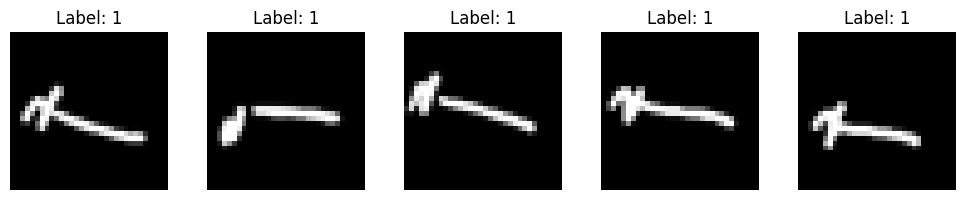

Displayed 5 sample images with their labels.


In [ ]:
if not train_images_df.empty:
    # Reshape and display a few sample images
    num_samples_to_display = 5
    plt.figure(figsize=(10, 2))

    for i in range(num_samples_to_display):
        image_pixels = train_images_df.iloc[i].values
        # Assuming images are 32x32 grayscale
        image = image_pixels.reshape(32, 32)

        plt.subplot(1, num_samples_to_display, i + 1)
        plt.imshow(image, cmap='gray')
        plt.title(f'Label: {train_labels_df.iloc[i, 0]}')
        plt.axis('off')

    plt.tight_layout()
    plt.show()

    print(f'Displayed {num_samples_to_display} sample images with their labels.')


IMAGE PROCESSING

In [ ]:
import pandas as pd
import numpy as np

# Define paths for test data
test_images_path = '/content/extracted_archive/csvTestImages 3360x1024.csv'
test_labels_path = '/content/extracted_archive/csvTestLabel 3360x1.csv'

# 1. Load Test Data
test_images_df = pd.read_csv(test_images_path, header=None)
test_labels_df = pd.read_csv(test_labels_path, header=None)

# 2. Normalize pixel values (0-255 -> 0-1)
# This is a 'small' but effective processing step for grayscale images
X_train = train_images_df.values.astype('float32') / 255.0
X_test = test_images_df.values.astype('float32') / 255.0

# 3. Reshape to (Samples, Width, Height, Channels)
X_train = X_train.reshape(-1, 32, 32, 1)
X_test = X_test.reshape(-1, 32, 32, 1)

# 4. Prepare labels (subtract 1 if labels start from 1 to make them 0-indexed for many ML frameworks)
y_train = train_labels_df.values.flatten() - 1
y_test = test_labels_df.values.flatten() - 1

print(f'Processed Training Shape: {X_train.shape}')
print(f'Processed Test Shape: {X_test.shape}')
print(f'Pixel range: {X_train.min()} to {X_train.max()}')

Processed Training Shape: (13440, 32, 32, 1)
Processed Test Shape: (3360, 32, 32, 1)
Pixel range: 0.0 to 1.0


### Processing Summary
- **Grayscale Conversion**: The data was already stored as grayscale intensity values.
- **Normalization**: Scaled all pixel values to the `[0, 1]` range.
- **Reshaping**: Converted flat 1024 vectors into `32x32x1` tensors, ready for Convolutional Neural Networks (CNNs).
- **Label Adjustment**: Converted labels to 0-indexed values.

Model Development: Naive Bayes Classification
We will use the `GaussianNB` classifier from scikit-learn. Since Naive Bayes expects a 2D input (samples, features), we will flatten the processed images back into vectors while retaining the normalized values.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Flatten the processed images for Naive Bayes (NB requires 2D input)
X_train_flat = X_train.reshape(X_train.shape[0], -1)
X_test_flat = X_test.reshape(X_test.shape[0], -1)

# 2. Split training data to create a validation set (80% train, 20% validation)
X_train_sub, X_val, y_train_sub, y_val = train_test_split(
    X_train_flat, y_train, test_size=0.2, random_state=42, stratify=y_train
)

# 3. Initialize and train the Gaussian Naive Bayes model
nb_classifier = GaussianNB()
nb_classifier.fit(X_train_sub, y_train_sub)

# 4. Predict on the test set
y_pred = nb_classifier.predict(X_test_flat)

print("Model training and prediction complete.")

Model training and prediction complete.


Testing With An Unseen Image

### Model Performance Metrics (Summary)

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Define arabic_chars as placeholder labels (assuming 28 unique classes, 0-indexed)
arabic_chars = [f'Char_{i}' for i in range(28)]

# Calculate overall accuracy
accuracy = accuracy_score(y_test, y_pred)

# Generate classification report to get precision, recall, f1-score (macro avg for overall view)
report = classification_report(y_test, y_pred, target_names=arabic_chars, output_dict=True)

precision = report['macro avg']['precision']
recall = report['macro avg']['recall']
f1 = report['macro avg']['f1-score']

print(f"Overall Accuracy: {accuracy:.4f}")
print(f"Macro Average Precision: {precision:.4f}")
print(f"Macro Average Recall: {recall:.4f}")
print(f"Macro Average F1-Score: {f1:.4f}")

Overall Accuracy: 0.1506
Macro Average Precision: 0.2079
Macro Average Recall: 0.1506
Macro Average F1-Score: 0.1215


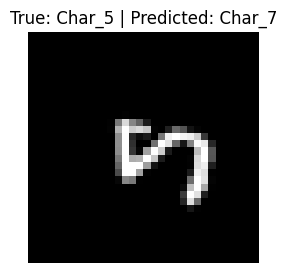

Selected image index: 1186
True Character: Char_5 (Label: 5)
Predicted Character: Char_7 (Label: 7)


In [ ]:
import random
import matplotlib.pyplot as plt

# Select a random index for an unseen image from the test set
random_idx = random.randint(0, len(X_test_flat) - 1)

# Get the image and its true label
unseen_image_flat = X_test_flat[random_idx].reshape(1, -1)
unseen_image_display = X_test[random_idx].reshape(32, 32)
true_label_idx = y_test[random_idx]

# Predict the character for the unseen image
predicted_label_idx = nb_classifier.predict(unseen_image_flat)[0]

# Map numerical labels to Arabic characters
true_char = arabic_chars[true_label_idx]
predicted_char = arabic_chars[predicted_label_idx]

# Display the image and comparison
plt.figure(figsize=(3, 3))
plt.imshow(unseen_image_display, cmap='gray')
plt.title(f"True: {true_char} | Predicted: {predicted_char}")
plt.axis('off')
plt.show()

print(f"Selected image index: {random_idx}")
print(f"True Character: {true_char} (Label: {true_label_idx})")
print(f"Predicted Character: {predicted_char} (Label: {predicted_label_idx})")

TRAINING USING NAIVE-BAYES WITH PCA




In [ ]:
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

# Initialize PCA to retain 95% of variance
pca = PCA(n_components=0.95)

# Create a pipeline with PCA and Gaussian Naive Bayes
pipeline_nb_pca = Pipeline([
    ('pca', pca),
    ('nb', GaussianNB())
])

# Train the pipeline on the training data
pipeline_nb_pca.fit(X_train_flat, y_train)

# Predict on the test set using the pipeline
y_pred_pca_nb = pipeline_nb_pca.predict(X_test_flat)

print(f"Number of components selected by PCA: {pca.n_components_}")
print("Naive Bayes model with PCA preprocessing trained and predictions made.")

Number of components selected by PCA: 216
Naive Bayes model with PCA preprocessing trained and predictions made.


MODEL PERFOMANCE METRICS

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

# Calculate overall accuracy for NB with PCA
accuracy_pca_nb = accuracy_score(y_test, y_pred_pca_nb)

# Generate classification report for NB with PCA
report_pca_nb = classification_report(y_test, y_pred_pca_nb, target_names=arabic_chars, output_dict=True, zero_division=0)

precision_pca_nb = report_pca_nb['macro avg']['precision']
recall_pca_nb = report_pca_nb['macro avg']['recall']
f1_pca_nb = report_pca_nb['macro avg']['f1-score']

print("\n--- Naive Bayes with PCA Performance Metrics ---")
print(f"Overall Accuracy: {accuracy_pca_nb:.4f}")
print(f"Macro Average Precision: {precision_pca_nb:.4f}")
print(f"Macro Average Recall: {recall_pca_nb:.4f}")
print(f"Macro Average F1-Score: {f1_pca_nb:.4f}")


--- Naive Bayes with PCA Performance Metrics ---
Overall Accuracy: 0.2940
Macro Average Precision: 0.3250
Macro Average Recall: 0.2940
Macro Average F1-Score: 0.2903


CONFUSION MATRIX

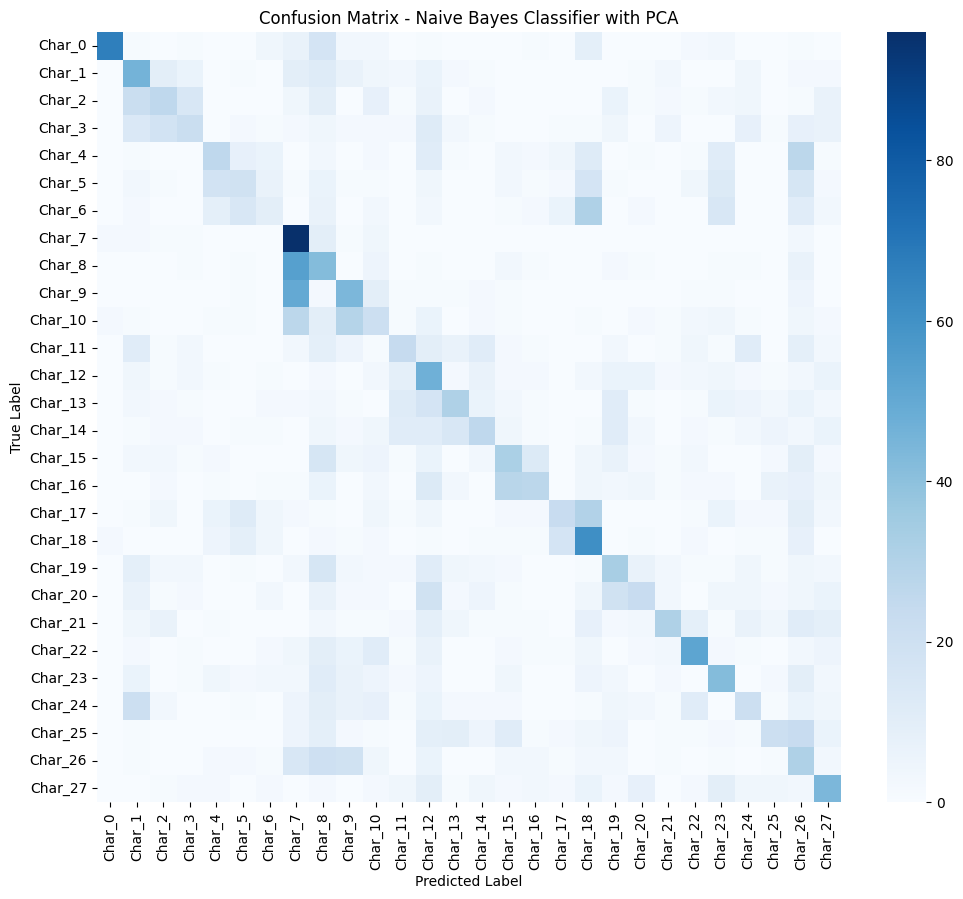

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix for NB with PCA
cm_pca_nb = confusion_matrix(y_test, y_pred_pca_nb)

# Plot the confusion matrix
plt.figure(figsize=(12, 10)) # Medium size figure
sns.heatmap(cm_pca_nb, annot=False, cmap='Blues', xticklabels=arabic_chars, yticklabels=arabic_chars)
plt.title('Confusion Matrix - Naive Bayes Classifier with PCA')
plt.xlabel('Predicted Label')
plt.ylabel('True Label'-)
plt.show()